In [ ]:
!pip install torchvision

In [ ]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [ ]:
# images load => transform => dataset of all imgs
class ImageProcessor:
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:

transformations = transforms.Compose([
    transforms.CenterCrop(178), # 178x218 => 178x178
    transforms.Resize(64), # 64x64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1]
])

In [21]:
root_dir_path = "/content/img_align_celeba"

dataset = ImageProcessor(root_dir_path, transformations)
print(f"Loaded {len(dataset)} images")

Loaded 202599 images


In [22]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [24]:
## Generator Network

In [25]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [26]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels),
            nn.Tanh() # [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64)
        return img

        # fake img => 64 x 64 x 3 x batch_size

In [27]:
## Discriminator Network

In [28]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D

            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid() # probability of being real/fake
        )

    def forward(self, img):
        return self.model(img)

In [29]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [30]:
import torch
# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is cuda


In [31]:
generator = generator.to(device)
discriminator = discriminator.to(device)

In [32]:
## Training the GAN

In [33]:
def train(generator, discriminator, dataloader, epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0....]

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device))

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}.... D-loss: {d_loss}")

        # save generated imgs for each epoch
        save_generated_images(generator, epoch, device)

In [34]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: 1/5... batch: 1... G-loss:0.7261455059051514.... D-loss: 0.6934925317764282
for epoch: 1/5... batch: 51... G-loss:0.9885807037353516.... D-loss: 0.2766200006008148
for epoch: 1/5... batch: 101... G-loss:2.161357879638672.... D-loss: 0.17048276960849762
for epoch: 1/5... batch: 151... G-loss:1.246381163597107.... D-loss: 0.19251707196235657
for epoch: 1/5... batch: 201... G-loss:2.2323176860809326.... D-loss: 0.12817849218845367
for epoch: 1/5... batch: 251... G-loss:2.172199010848999.... D-loss: 0.09489943832159042
for epoch: 1/5... batch: 301... G-loss:3.6826064586639404.... D-loss: 0.05415259301662445
for epoch: 1/5... batch: 351... G-loss:3.0155434608459473.... D-loss: 0.1082395389676094
for epoch: 1/5... batch: 401... G-loss:8.133445739746094.... D-loss: 0.3627285361289978
for epoch: 1/5... batch: 451... G-loss:2.259746551513672.... D-loss: 0.04273118078708649
for epoch: 1/5... batch: 501... G-loss:4.311420917510986.... D-loss: 0.038098253309726715
for epoch: 1/5... batc

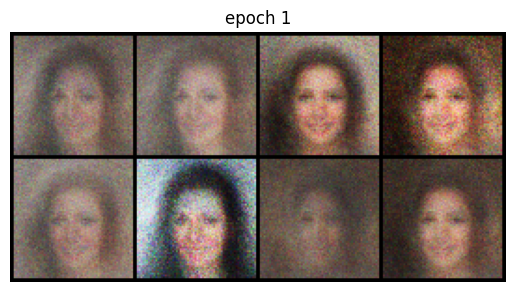

for epoch: 2/5... batch: 1... G-loss:3.3409252166748047.... D-loss: 0.29053229093551636
for epoch: 2/5... batch: 51... G-loss:2.5259156227111816.... D-loss: 0.5483880043029785
for epoch: 2/5... batch: 101... G-loss:2.804612636566162.... D-loss: 0.29740846157073975
for epoch: 2/5... batch: 151... G-loss:2.9084866046905518.... D-loss: 0.2770850658416748
for epoch: 2/5... batch: 201... G-loss:2.6381688117980957.... D-loss: 0.3305692970752716
for epoch: 2/5... batch: 251... G-loss:3.1276071071624756.... D-loss: 0.37673619389533997
for epoch: 2/5... batch: 301... G-loss:3.3241512775421143.... D-loss: 0.2780534625053406
for epoch: 2/5... batch: 351... G-loss:3.2165393829345703.... D-loss: 0.2878352999687195
for epoch: 2/5... batch: 401... G-loss:2.7495641708374023.... D-loss: 0.5145108699798584
for epoch: 2/5... batch: 451... G-loss:2.5551366806030273.... D-loss: 0.31257328391075134
for epoch: 2/5... batch: 501... G-loss:2.586670160293579.... D-loss: 0.35502174496650696
for epoch: 2/5... bat

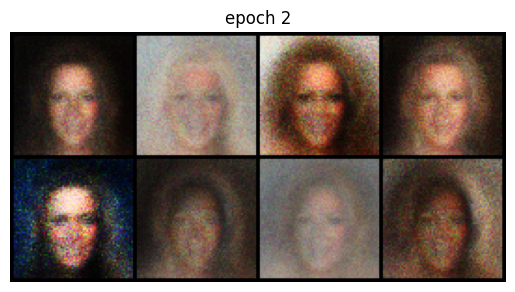

for epoch: 3/5... batch: 1... G-loss:2.7170422077178955.... D-loss: 0.26022225618362427
for epoch: 3/5... batch: 51... G-loss:1.8351491689682007.... D-loss: 0.4131302237510681
for epoch: 3/5... batch: 101... G-loss:2.477235794067383.... D-loss: 0.3823505938053131
for epoch: 3/5... batch: 151... G-loss:2.067854404449463.... D-loss: 0.3623200058937073
for epoch: 3/5... batch: 201... G-loss:2.0229411125183105.... D-loss: 0.4440528154373169
for epoch: 3/5... batch: 251... G-loss:2.587728500366211.... D-loss: 0.4167536199092865
for epoch: 3/5... batch: 301... G-loss:2.3324825763702393.... D-loss: 0.34029752016067505
for epoch: 3/5... batch: 351... G-loss:1.8593764305114746.... D-loss: 0.4878106117248535
for epoch: 3/5... batch: 401... G-loss:1.9438681602478027.... D-loss: 0.4507552981376648
for epoch: 3/5... batch: 451... G-loss:2.193593740463257.... D-loss: 0.39728230237960815
for epoch: 3/5... batch: 501... G-loss:2.7212815284729004.... D-loss: 0.34333595633506775
for epoch: 3/5... batch:

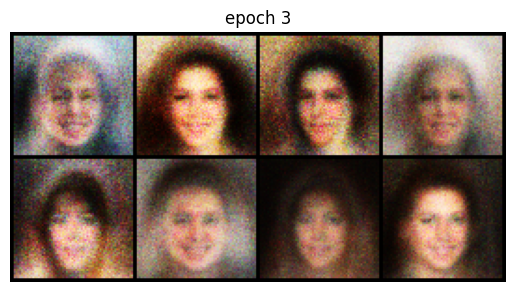

for epoch: 4/5... batch: 1... G-loss:1.5734236240386963.... D-loss: 0.5335824489593506
for epoch: 4/5... batch: 51... G-loss:2.4329428672790527.... D-loss: 0.5443944931030273
for epoch: 4/5... batch: 101... G-loss:2.360729455947876.... D-loss: 0.44889581203460693
for epoch: 4/5... batch: 151... G-loss:1.9076770544052124.... D-loss: 0.4193929433822632
for epoch: 4/5... batch: 201... G-loss:1.8703060150146484.... D-loss: 0.4224027097225189
for epoch: 4/5... batch: 251... G-loss:1.5096392631530762.... D-loss: 0.449087917804718
for epoch: 4/5... batch: 301... G-loss:1.9290449619293213.... D-loss: 0.4337228536605835
for epoch: 4/5... batch: 351... G-loss:1.798551321029663.... D-loss: 0.4180777072906494
for epoch: 4/5... batch: 401... G-loss:2.1272873878479004.... D-loss: 0.4192255437374115
for epoch: 4/5... batch: 451... G-loss:1.7548877000808716.... D-loss: 0.6034959554672241
for epoch: 4/5... batch: 501... G-loss:2.150054454803467.... D-loss: 0.4288085103034973
for epoch: 4/5... batch: 55

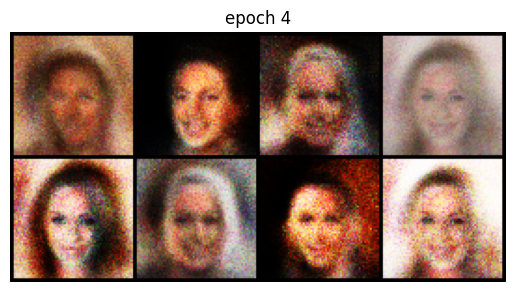

for epoch: 5/5... batch: 1... G-loss:1.8144125938415527.... D-loss: 0.5039830803871155
for epoch: 5/5... batch: 51... G-loss:2.1460957527160645.... D-loss: 0.5102602243423462
for epoch: 5/5... batch: 101... G-loss:2.4723567962646484.... D-loss: 0.4794999957084656
for epoch: 5/5... batch: 151... G-loss:1.3408393859863281.... D-loss: 0.5285223126411438
for epoch: 5/5... batch: 201... G-loss:2.0109493732452393.... D-loss: 0.4644535183906555
for epoch: 5/5... batch: 251... G-loss:1.7798429727554321.... D-loss: 0.5164270401000977
for epoch: 5/5... batch: 301... G-loss:1.6302852630615234.... D-loss: 0.5316085815429688
for epoch: 5/5... batch: 351... G-loss:2.132063388824463.... D-loss: 0.5106095671653748
for epoch: 5/5... batch: 401... G-loss:1.5713157653808594.... D-loss: 0.45419663190841675
for epoch: 5/5... batch: 451... G-loss:1.7252647876739502.... D-loss: 0.4838452637195587
for epoch: 5/5... batch: 501... G-loss:1.9382317066192627.... D-loss: 0.43221133947372437
for epoch: 5/5... batch

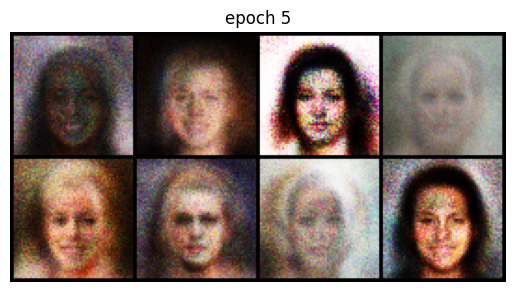

In [35]:
train(generator, discriminator, dataloader, epochs=5)